In [1]:
# ============================================================
# 0. 필요한 라이브러리
# ============================================================

from pathlib import Path
from collections import Counter
from itertools import combinations
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from IPython.display import display


# ============================================================
# 1. 프로젝트 경로 설정
# ============================================================

# 팀 프로젝트 안에서 시각화 파일을 따로 관리하는 폴더
BASE_DIR = Path(
    r"C:\Users\Playdata\Desktop\team3_ 프로젝트1"
    r"\mle-01-p1-team3\인벤데이터 시각화"
)

# 전처리된 데이터가 저장된 폴더
OUTPUT_DIR = BASE_DIR / "outputs"

# 완성된 그래프를 저장할 폴더
FIG_DIR = BASE_DIR / "figures"

# figures 폴더가 없다면 자동 생성
FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. 색상 및 Matplotlib 기본 설정
# ============================================================

# 메이플스토리 UI를 연상시키는
# 주황 → 빨강 → 짙은 갈색 계열만 사용한다.
#
# 변수명은 특정 게임 이름을 붙이지 않고
# 그래프에서의 역할을 기준으로 지정한다.

PRIMARY = "#F28C28"      # 주황
SECONDARY = "#E6513E"    # 빨강
DEEP = "#8F3324"         # 진한 적갈색
SOFT = "#F6B957"         # 밝은 주황

TEXT = "#49352A"         # 기본 글자
MUTED = "#806C60"        # 보조 글자
GRID = "#E9DED6"         # 보조선


# Windows에서 한글이 깨지지 않도록 설정
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 기본 배경은 과하게 꾸미지 않고 흰색 유지
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"


# ============================================================
# 3. 분석 데이터 불러오기
# ============================================================

# tokens가 Python list 형태로 보존되어 있기 때문에
# CSV가 아닌 pickle을 사용한다.
qna_anal = pd.read_pickle(
    OUTPUT_DIR / "qna_anal.pkl"
)


# ============================================================
# 4. 신규·복귀 여부 불러오기
# ============================================================

# 가장 최근 분석 코드에서 is_new_returning 컬럼을
# qna_anal 안에 저장했다면 그 값을 그대로 사용한다.
#
# 여기에서는 신규·복귀 키워드를 다시 정의하거나
# regex를 새로 적용하지 않는다.

if "is_new_returning" in qna_anal.columns:

    target_mask = (
        qna_anal["is_new_returning"]
        .fillna(False)
        .astype(bool)
    )

else:

    # 이전 버전 데이터처럼 condition.pkl이 따로 저장되어 있다면
    # 기존 condition을 그대로 사용한다.
    condition_path = OUTPUT_DIR / "condition.pkl"

    if not condition_path.exists():
        raise FileNotFoundError(
            "is_new_returning 컬럼도 없고 "
            "condition.pkl도 찾을 수 없습니다."
        )

    with open(condition_path, "rb") as file:
        condition = pickle.load(file)

    # condition이 Series가 아니라 배열 형태로 저장된 경우
    # qna_anal의 인덱스를 이용해 Series로 변환한다.
    if not isinstance(condition, pd.Series):
        condition = pd.Series(
            condition,
            index=qna_anal.index
        )

    # 분석 데이터와 인덱스를 맞춘다.
    target_mask = (
        condition
        .reindex(
            qna_anal.index,
            fill_value=False
        )
        .astype(bool)
    )


# ============================================================
# 5. 데이터 검증
# ============================================================

# 앞으로 사용할 필수 컬럼
required_columns = {
    "title",
    "category",
    "views",
    "likes",
    "tokens"
}

# 없는 컬럼 확인
missing_columns = (
    required_columns
    - set(qna_anal.columns)
)

assert not missing_columns, (
    f"필수 컬럼이 없습니다: {missing_columns}"
)

# 신규·복귀 필터 길이와 데이터 행 수가 같은지 확인
assert len(target_mask) == len(qna_anal), (
    "신규·복귀 필터와 qna_anal의 길이가 다릅니다."
)


# 조회수와 좋아요는 혹시 모를 문자열 데이터를 대비해서
# 숫자로 다시 한 번 안전하게 변환한다.
qna_anal["views"] = (
    pd.to_numeric(
        qna_anal["views"],
        errors="coerce"
    )
    .fillna(0)
    .astype(int)
)

qna_anal["likes"] = (
    pd.to_numeric(
        qna_anal["likes"],
        errors="coerce"
    )
    .fillna(0)
    .astype(int)
)


# ============================================================
# 6. 신규·복귀 / 일반 질문 분리
# ============================================================

# 신규·복귀로 판별된 게시글만 따로 추출
target_posts = (
    qna_anal
    .loc[target_mask]
    .copy()
)

# 신규·복귀 게시글을 제외한 나머지 전체
general_posts = (
    qna_anal
    .loc[~target_mask]
    .copy()
)


# 데이터가 정확하게 두 집단으로 분리됐는지 확인
assert (
    len(target_posts)
    + len(general_posts)
    == len(qna_anal)
)

# 같은 게시글이 양쪽 집단에 동시에 존재하면 안 된다.
assert set(target_posts.index).isdisjoint(
    general_posts.index
)


print("===== 데이터 확인 =====")

print(
    f"전체 게시글       : "
    f"{len(qna_anal):,}개"
)

print(
    f"일반 질문         : "
    f"{len(general_posts):,}개"
)

print(
    f"신규·복귀 질문    : "
    f"{len(target_posts):,}개"
)

===== 데이터 확인 =====
전체 게시글       : 4,157개
일반 질문         : 3,059개
신규·복귀 질문    : 1,098개


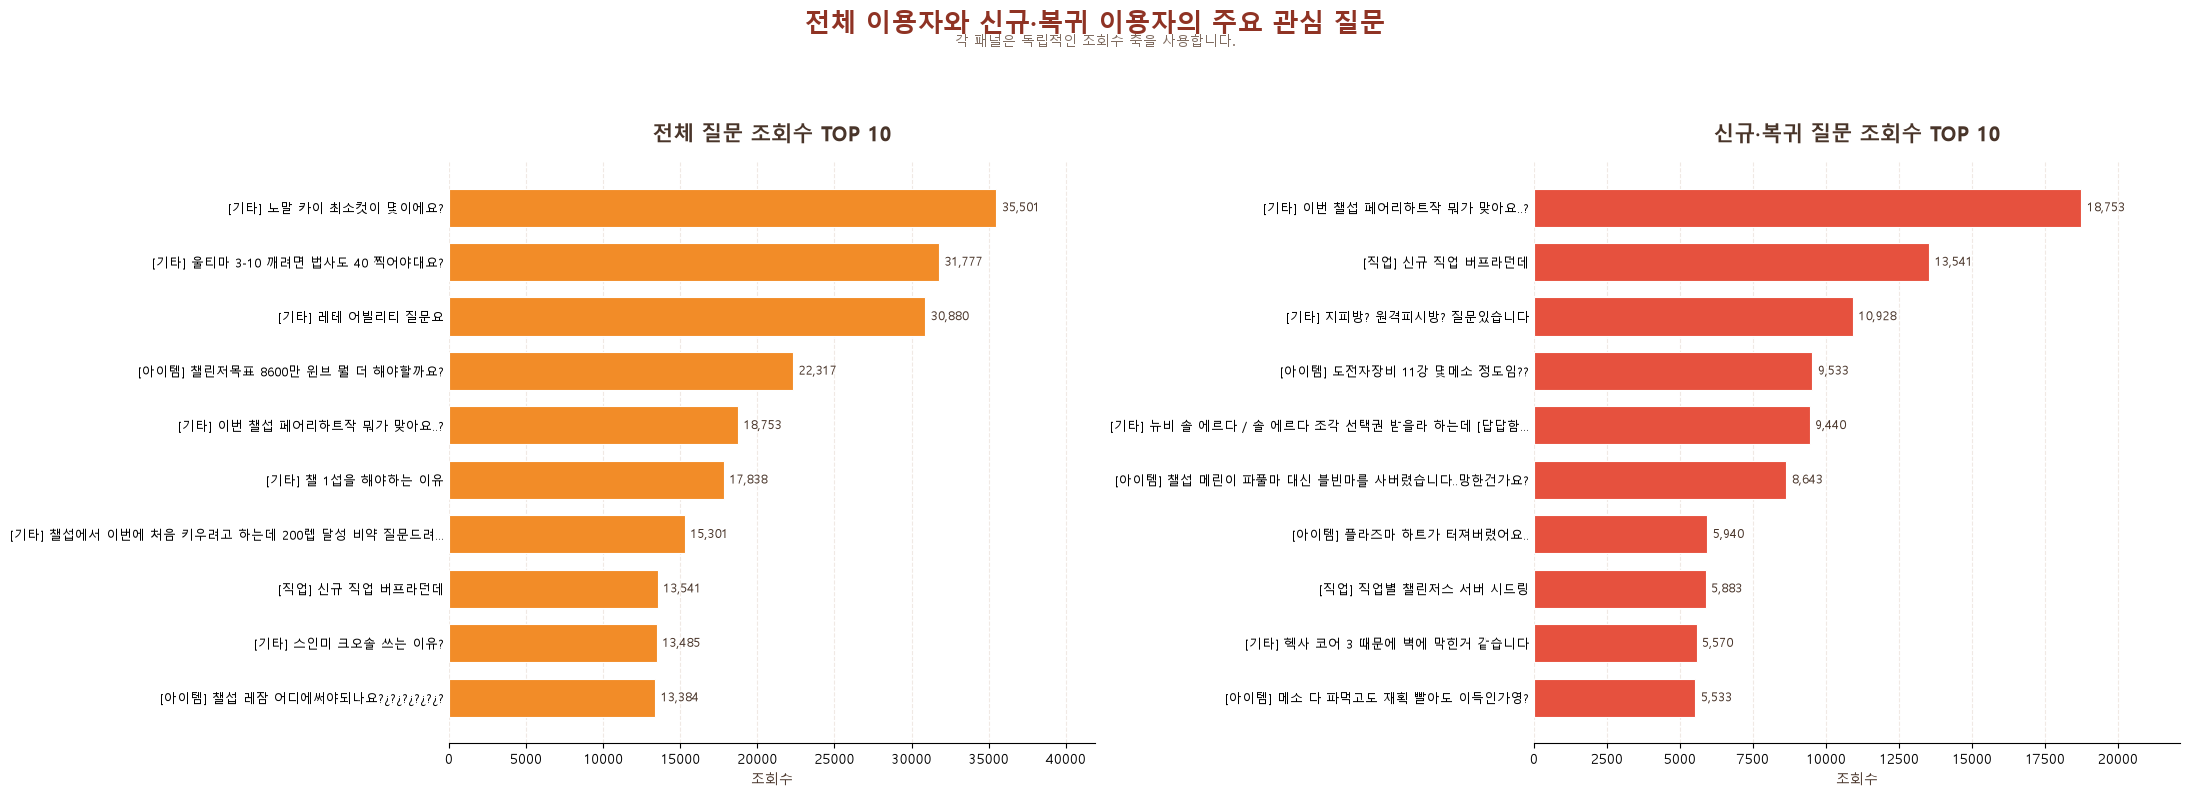

In [2]:
# ============================================================
# 그래프 1
# 전체 질문 조회수 TOP 10
# vs
# 신규·복귀 질문 조회수 TOP 10
# ============================================================


# ------------------------------------------------------------
# 1. 그래프에 표시할 제목을 적당한 길이로 줄이는 함수
# ------------------------------------------------------------

def shorten_title(
    title,
    max_length=36
):
    """
    게시글 원본 제목은 그대로 유지하고,
    그래프에서만 너무 긴 제목을 줄여서 보여준다.
    """

    # 줄바꿈과 연속 공백 제거
    text = " ".join(
                "# ============================================================",
                "# 16. 신규·복귀 질문에서 상대적으로 많이 등장한 키워드 표",
                "# ============================================================",
                "",
                "target_distinctive_table = (",
                "    target_distinctive[",
                "        [",
                "            \"word\",",
                "            \"general_rate\",",
                "            \"target_rate\",",
                "            \"rate_gap\"",
                "        ]",
                "    ]",
                "    .rename(columns={",
                "        \"word\": \"키워드\",",
                "        \"general_rate\": \"일반 질문 비율(%)\",",
                "        \"target_rate\": \"신규·복귀 질문 비율(%)\",",
                "        \"rate_gap\": \"차이(%p)\"",
                "    })",
                ")",
                "",
                "display(",
                "    target_distinctive_table.style",
                "    .format({",
                "        \"일반 질문 비율(%)\": \"{:.1f}\",",
                "        \"신규·복귀 질문 비율(%)\": \"{:.1f}\",",
                "        \"차이(%p)\": \"{:+.1f}\"",
                "    })",
                "    .background_gradient(",
                "        subset=[\"차이(%p)\"],",
                "        cmap=\"Oranges\"",
                "    )",
                ")"
    )

    # 지정 길이보다 짧다면 그대로 반환
    if len(text) <= max_length:
        return text

    # 너무 길면 마지막에 ...을 표시
    return text[:max_length] + "..."


# ------------------------------------------------------------
# 2. 조회수 기준 TOP 10 생성 함수
# ------------------------------------------------------------

def get_top10(data):
    """
    입력된 데이터 전체에서
    조회수가 높은 게시글 10개를 추출한다.
    """

    result = (
        data
        .nlargest(
            10,
            "views"
        )
        [
            [
                "title",
                "category",
                "views"
            ]
        ]
        .copy()
    )

    # 카테고리와 제목을 같이 보여준다.
    result["label"] = result.apply(
        lambda row:
            f"[{row['category']}] "
            f"{shorten_title(row['title'])}",
        axis=1
    )

    # 가로 막대그래프에서는
    # 작은 값부터 그려야 큰 값이 위쪽에 표시된다.
    result = result.sort_values(
        "views",
        ascending=True
    )

    return result


# 전체 데이터 TOP 10
overall_top10 = get_top10(
    qna_anal
)

# 신규·복귀 데이터 TOP 10
target_top10 = get_top10(
    target_posts
)


# ------------------------------------------------------------
# 3. 막대그래프 하나를 그리는 함수
# ------------------------------------------------------------

def draw_top10(
    ax,
    data,
    title,
    color
):
    """
    전달받은 axis에
    조회수 TOP 10 가로 막대그래프를 그린다.
    """

    y = np.arange(
        len(data)
    )

    # 가로 막대 생성
    bars = ax.barh(
        y,
        data["views"],
        color=color,
        edgecolor="white",
        linewidth=0.8,
        height=0.7
    )

    # 게시글 제목 표시
    ax.set_yticks(
        y
    )

    ax.set_yticklabels(
        data["label"],
        fontsize=9
    )

    # 그래프 제목
    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        color=TEXT,
        pad=15
    )

    # X축 제목
    ax.set_xlabel(
        "조회수",
        color=TEXT
    )

    # 각 막대 끝에 실제 조회수 표시
    ax.bar_label(
        bars,
        labels=[
            f"{value:,}"
            for value
            in data["views"]
        ],
        padding=4,
        fontsize=9,
        color=TEXT
    )

    # 숫자가 그래프 밖으로 잘리지 않도록 여백 확보
    ax.set_xlim(
        0,
        data["views"].max() * 1.18
    )

    # X축 가이드선만 약하게 표시
    ax.grid(
        axis="x",
        linestyle="--",
        color=GRID,
        alpha=0.65
    )

    ax.set_axisbelow(True)

    # 불필요한 테두리 제거
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # 제목 옆의 Y축 눈금선 제거
    ax.tick_params(
        axis="y",
        length=0
    )


# ------------------------------------------------------------
# 4. 두 TOP 10 그래프 출력
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(22, 8)
)


# 왼쪽: 전체 질문
draw_top10(
    ax=axes[0],
    data=overall_top10,
    title="전체 질문 조회수 TOP 10",
    color=PRIMARY
)


# 오른쪽: 신규·복귀 질문
draw_top10(
    ax=axes[1],
    data=target_top10,
    title="신규·복귀 질문 조회수 TOP 10",
    color=SECONDARY
)


# 전체 그래프 제목
fig.suptitle(
    "전체 이용자와 신규·복귀 이용자의 주요 관심 질문",
    fontsize=19,
    fontweight="bold",
    color=DEEP,
    y=0.99
)


# 두 패널의 조회수 규모가 크게 다를 수 있기 때문에
# 각각 독립적인 X축을 사용했다는 점을 명시한다.
fig.text(
    0.5,
    0.945,
    "각 패널은 독립적인 조회수 축을 사용합니다.",
    ha="center",
    fontsize=10,
    color=MUTED
)


fig.tight_layout(
    rect=(0, 0, 1, 0.92)
)


# 이미지 저장
fig.savefig(
    FIG_DIR / "01_top10_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 5. TOP 10 결과 CSV 저장
# ------------------------------------------------------------

overall_top10[
    [
        "title",
        "category",
        "views"
    ]
].to_csv(
    OUTPUT_DIR / "overall_top10.csv",
    index=False,
    encoding="utf-8-sig"
)


target_top10[
    [
        "title",
        "category",
        "views"
    ]
].to_csv(
    OUTPUT_DIR / "target_top10.csv",
    index=False,
    encoding="utf-8-sig"
)

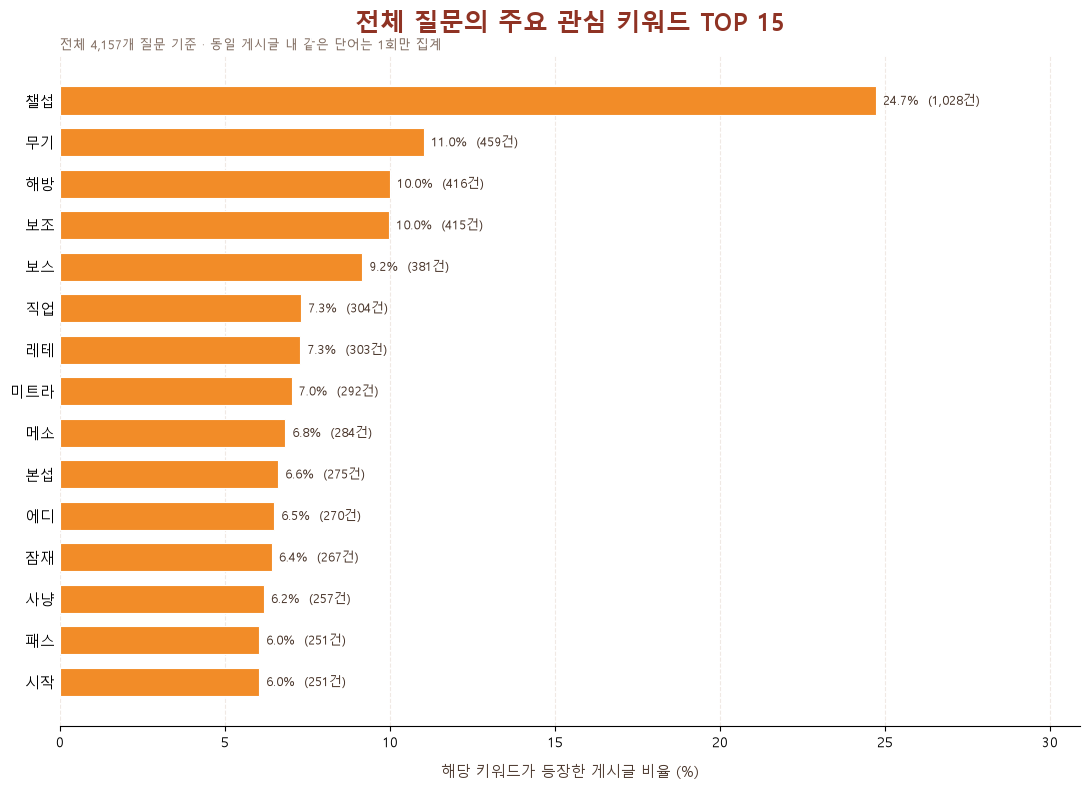

,word,document_count,document_rate
0,챌섭,1028,24.729372
1,무기,459,11.041617
2,해방,416,10.007217
3,보조,415,9.983161
4,보스,381,9.165263
5,직업,304,7.312966
6,레테,303,7.288910
7,미트라,292,7.024296
8,메소,284,6.831850
9,본섭,275,6.615348


In [3]:
# ============================================================
# 그래프 2
# 전체 질문에서 많이 등장하는 주요 키워드 TOP 15
# ============================================================

from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. 키워드 분석 설정
# ============================================================

# 그래프에 표시할 키워드 개수
TOP_N = 15


# ============================================================
# 2. 신규·복귀 판별 관련 단어 제외
# ============================================================

# 신규·복귀 질문을 골라낼 때 사용한 표현은
# 실제 관심 주제가 아니라 "집단을 구분하는 기준"이다.
#
# 예를 들어 신규·복귀 질문에서
#
#   뉴비      1위
#   복귀      2위
#
# 처럼 나와도 당연한 결과이므로 분석적인 의미가 없다.
#
# 따라서 키워드 시각화 단계에서만 제외한다.
#
# "복귀유저"는 신규 판별 기준을 새로 추가하는 것이 아니라,
# 형태소 분석 결과 하나의 토큰으로 남아 있을 경우
# 그래프에서 제거하기 위한 표현이다.

EXCLUDE_WORDS = {
    "뉴비",
    "메린이",
    "메린",
    "복귀",
    "복귀유저",
    "유입",
    "입문",
    "초보",
}


# ============================================================
# 3. 게시글 기준 키워드 통계 함수
# ============================================================

def keyword_document_stats(
    data: pd.DataFrame,
    exclude_words: set
) -> pd.DataFrame:
    """
    각 단어가 '몇 개의 게시글에서 등장했는지' 계산한다.

    예)
    한 게시글의 tokens가

        ["장비", "세팅", "장비"]

    라고 하더라도 장비를 2회로 계산하지 않고

        장비 → 게시글 1건
        세팅 → 게시글 1건

    으로 계산한다.

    이렇게 해야 특정 작성자가 같은 단어를 반복해서 쓴 것이
    전체 키워드 중요도를 과도하게 높이지 않는다.
    """

    # 분석할 게시글이 없다면 이후 비율 계산이 불가능하다.
    if len(data) == 0:
        raise ValueError(
            "키워드를 분석할 게시글이 없습니다."
        )

    # 단어별 등장 게시글 수를 저장한다.
    word_counter = Counter()


    # --------------------------------------------------------
    # 게시글별 tokens 확인
    # --------------------------------------------------------

    for tokens in data["tokens"]:

        # tokens가 정상적인 리스트 계열 데이터가 아니라면 건너뛴다.
        if not isinstance(
            tokens,
            (
                list,
                tuple,
                set,
                np.ndarray
            )
        ):
            continue


        # ----------------------------------------------------
        # 같은 게시글에서 동일 단어는 한 번만 사용
        # ----------------------------------------------------

        words = {
            str(word).strip()

            for word in tokens

            if (
                isinstance(word, str)

                # 한 글자 토큰은 사용하지 않는다.
                and len(word.strip()) >= 2

                # 신규·복귀 판별용 단어 제거
                and word.strip() not in exclude_words
            )
        }


        # 현재 게시글의 단어들을
        # 각각 게시글 등장 1회로 누적한다.
        word_counter.update(
            words
        )


    # --------------------------------------------------------
    # DataFrame 생성
    # --------------------------------------------------------

    keyword_stats = pd.DataFrame(
        [
            {
                "word": word,

                # 해당 단어가 등장한 게시글 수
                "document_count": count,

                # 전체 게시글 중 해당 단어가 등장한 비율
                "document_rate": (
                    count
                    / len(data)
                    * 100
                )
            }

            for word, count
            in word_counter.items()
        ]
    )


    # 사용할 단어가 하나도 없다면 빈 DataFrame 반환
    if keyword_stats.empty:

        return pd.DataFrame(
            columns=[
                "word",
                "document_count",
                "document_rate"
            ]
        )


    # 등장 게시글 수가 많은 순서로 정렬
    keyword_stats = (
        keyword_stats
        .sort_values(
            [
                "document_count",
                "word"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(
            drop=True
        )
    )


    return keyword_stats


# ============================================================
# 4. 전체 질문 키워드 통계 계산
# ============================================================

overall_keyword_stats = keyword_document_stats(
    data=qna_anal,
    exclude_words=EXCLUDE_WORDS
)


# 상위 15개만 추출
overall_top_keywords = (
    overall_keyword_stats
    .head(TOP_N)
    .copy()
)


# 가로 막대그래프에서는
# 작은 값부터 먼저 그려야 가장 큰 단어가 위쪽에 표시된다.
overall_top_keywords = (
    overall_top_keywords
    .sort_values(
        "document_rate",
        ascending=True
    )
)


# ============================================================
# 5. 전체 질문 키워드 Bar Plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 8)
)


# Y축 위치
y = np.arange(
    len(overall_top_keywords)
)


# 가로 막대 생성
bars = ax.barh(
    y,
    overall_top_keywords["document_rate"],

    color=PRIMARY,

    edgecolor="white",
    linewidth=0.8,

    height=0.68
)


# Y축에 실제 단어 표시
ax.set_yticks(
    y
)

ax.set_yticklabels(
    overall_top_keywords["word"],
    fontsize=11
)


# ============================================================
# 6. 막대 오른쪽에 비율 + 실제 게시글 수 표시
# ============================================================

labels = [
    (
        f"{rate:.1f}%  "
        f"({count:,}건)"
    )

    for rate, count
    in zip(
        overall_top_keywords["document_rate"],
        overall_top_keywords["document_count"]
    )
]


ax.bar_label(
    bars,
    labels=labels,

    padding=5,

    fontsize=9,
    color=TEXT
)


# 막대 끝의 숫자가 잘리지 않도록 오른쪽 여백 확보
ax.set_xlim(
    0,
    overall_top_keywords["document_rate"].max()
    * 1.25
)


# ============================================================
# 7. 제목 및 축 설정
# ============================================================

ax.set_title(
    "전체 질문의 주요 관심 키워드 TOP 15",
    fontsize=18,
    fontweight="bold",
    color=DEEP,
    pad=18
)


ax.set_xlabel(
    "해당 키워드가 등장한 게시글 비율 (%)",
    fontsize=11,
    color=TEXT,
    labelpad=10
)


# 설명 문구
ax.text(
    0,
    1.01,

    (
        f"전체 {len(qna_anal):,}개 질문 기준 · "
        "동일 게시글 내 같은 단어는 1회만 집계"
    ),

    transform=ax.transAxes,

    fontsize=9,
    color=MUTED
)


# X축 보조선
ax.grid(
    axis="x",
    linestyle="--",
    color=GRID,
    alpha=0.65
)

ax.set_axisbelow(
    True
)


# 불필요한 테두리 제거
ax.spines["top"].set_visible(
    False
)

ax.spines["right"].set_visible(
    False
)

ax.spines["left"].set_visible(
    False
)


# 단어 옆 작은 눈금선 제거
ax.tick_params(
    axis="y",
    length=0
)


fig.tight_layout()


# ============================================================
# 8. 그래프 저장
# ============================================================

fig.savefig(
    FIG_DIR
    / "02_overall_keyword_top15.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 9. 분석 결과 CSV 저장
# ============================================================

overall_top_keywords[
    [
        "word",
        "document_count",
        "document_rate"
    ]
].sort_values(
    "document_rate",
    ascending=False
).to_csv(
    OUTPUT_DIR
    / "overall_keyword_top15.csv",

    index=False,
    encoding="utf-8-sig"
)


# 실제 값도 확인
display(
    overall_top_keywords[
        [
            "word",
            "document_count",
            "document_rate"
        ]
    ]
    .sort_values(
        "document_rate",
        ascending=False
    )
)

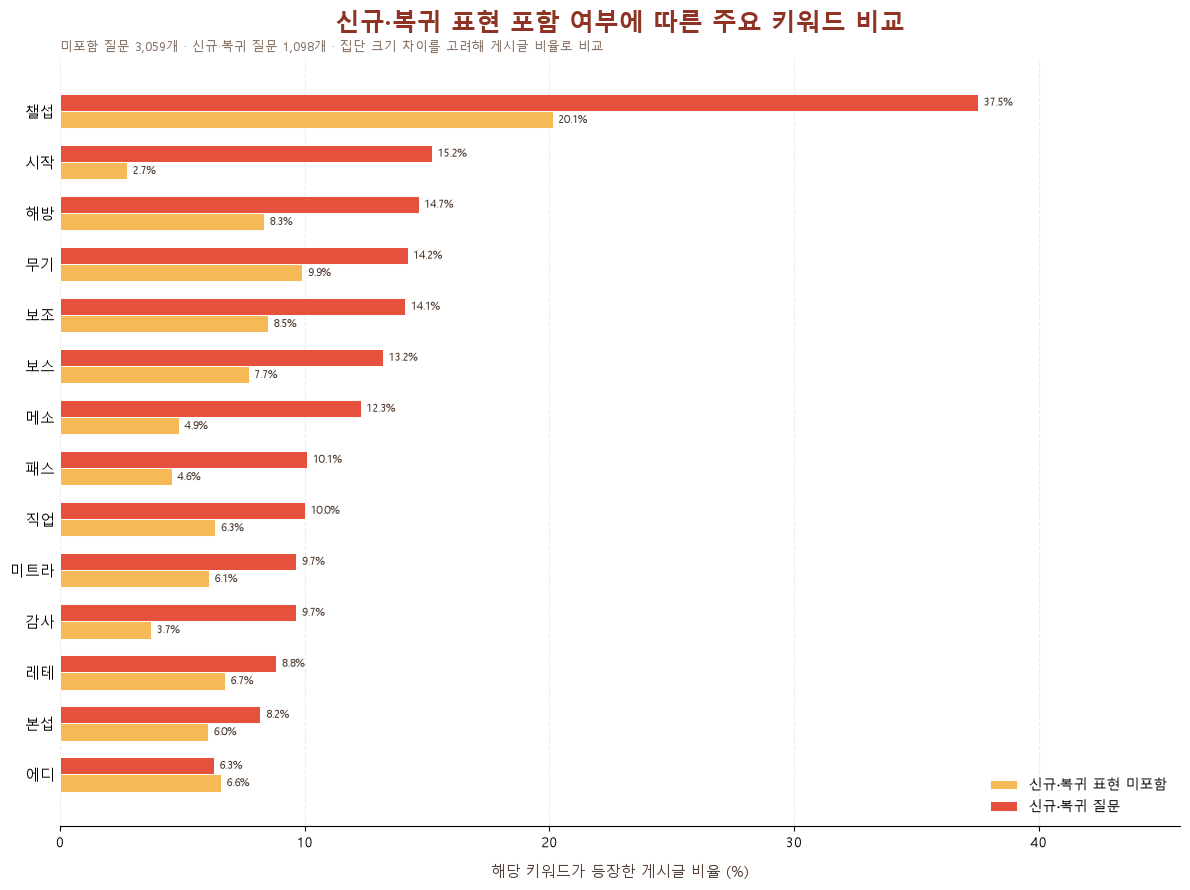

In [4]:
# ============================================================
# 그래프 3
# 신규·복귀 표현 포함 여부에 따른 주요 키워드 비교
# ============================================================


# ============================================================
# 1. 비교 설정
# ============================================================

# 각 집단에서 먼저 상위 10개 단어를 찾는다.
#
# 이후 두 집단의 상위 단어를 합친 뒤
# 최종적으로 최대 15개만 그래프에 표시한다.
#
# 이렇게 해야
#
# 일반 질문에서 중요한 단어
# +
# 신규·복귀 질문에서 중요한 단어
#
# 양쪽 모두 비교 후보에 들어갈 수 있다.

TOP_PER_GROUP = 10

MAX_COMPARE_WORDS = 15


# ============================================================
# 2. 일반 질문 / 신규·복귀 질문 키워드 통계 계산
# ============================================================

general_keyword_stats = keyword_document_stats(
    data=general_posts,
    exclude_words=EXCLUDE_WORDS
)


target_keyword_stats = keyword_document_stats(
    data=target_posts,
    exclude_words=EXCLUDE_WORDS
)


# ============================================================
# 3. 양쪽 집단에서 중요한 단어 후보 생성
# ============================================================

# 일반 질문에서 상위 10개 단어
general_top_words = set(
    general_keyword_stats
    .head(TOP_PER_GROUP)["word"]
)


# 신규·복귀 질문에서 상위 10개 단어
target_top_words = set(
    target_keyword_stats
    .head(TOP_PER_GROUP)["word"]
)


# 두 집단의 상위 단어 합집합
#
# 예:
#
# 일반:
# 장비 / 보스 / 직업 / 스킬
#
# 신규·복귀:
# 장비 / 추천 / 세팅 / 직업
#
# 최종 후보:
# 장비 / 보스 / 직업 / 스킬 / 추천 / 세팅

candidate_words = (
    general_top_words
    | target_top_words
)


# ============================================================
# 4. 빠르게 값을 조회하기 위해 단어를 index로 변경
# ============================================================

general_lookup = (
    general_keyword_stats
    .set_index("word")
)


target_lookup = (
    target_keyword_stats
    .set_index("word")
)


# ============================================================
# 5. 동일 단어의 두 집단 비율을 하나의 표로 생성
# ============================================================

comparison_rows = []


for word in candidate_words:

    # --------------------------------------------------------
    # 일반 질문
    # --------------------------------------------------------

    if word in general_lookup.index:

        general_count = int(
            general_lookup.loc[
                word,
                "document_count"
            ]
        )

        general_rate = float(
            general_lookup.loc[
                word,
                "document_rate"
            ]
        )

    else:

        general_count = 0
        general_rate = 0.0


    # --------------------------------------------------------
    # 신규·복귀 질문
    # --------------------------------------------------------

    if word in target_lookup.index:

        target_count = int(
            target_lookup.loc[
                word,
                "document_count"
            ]
        )

        target_rate = float(
            target_lookup.loc[
                word,
                "document_rate"
            ]
        )

    else:

        target_count = 0
        target_rate = 0.0


    # --------------------------------------------------------
    # 비교 결과 저장
    # --------------------------------------------------------

    comparison_rows.append(
        {
            "word": word,

            "general_count":
                general_count,

            "general_rate":
                general_rate,

            "target_count":
                target_count,

            "target_rate":
                target_rate,

            # 신규·복귀 질문 비율 - 일반 질문 비율
            #
            # 양수:
            # 신규·복귀 쪽에서 상대적으로 더 많이 등장
            #
            # 음수:
            # 일반 질문 쪽에서 상대적으로 더 많이 등장
            "rate_gap":
                target_rate
                - general_rate,

            # 최종 시각화 단어를 고를 때 사용
            "max_rate":
                max(
                    general_rate,
                    target_rate
                )
        }
    )


comparison = pd.DataFrame(
    comparison_rows
)


# ============================================================
# 6. 최종 비교 단어 선택
# ============================================================

# 한쪽 집단에서라도 높은 비율로 나타나는 단어를 우선한다.
#
# 단순 합산 빈도를 사용하지 않는 이유:
# 일반 질문의 게시글 수가 더 많기 때문에
# 단순 count 합산을 사용하면 일반 질문의 영향을 과도하게 받게 된다.

comparison = (
    comparison

    .sort_values(
        [
            "max_rate",
            "word"
        ],
        ascending=[
            False,
            True
        ]
    )

    .head(
        MAX_COMPARE_WORDS
    )

    .copy()
)


# 이제 max_rate는 시각화 선택용으로만 사용했으므로 제거
comparison = comparison.drop(
    columns="max_rate"
)


# ============================================================
# 7. 그래프 표시 순서 결정
# ============================================================

# 두 집단 중 더 높은 비율을 기준으로 정렬한다.
#
# 가로 막대그래프이므로
# 큰 값이 위에 표시되도록 작은 값부터 정렬한다.

comparison["plot_order"] = comparison[
    [
        "general_rate",
        "target_rate"
    ]
].max(
    axis=1
)


comparison_plot = (
    comparison
    .sort_values(
        "plot_order",
        ascending=True
    )
    .copy()
)


# ============================================================
# 8. 그룹형 가로 Bar Plot 생성
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 9)
)


# Y축 기본 위치
y = np.arange(
    len(comparison_plot)
)


# 한 단어에 두 개의 막대를 그리기 위한 높이
bar_height = 0.34


# ------------------------------------------------------------
# 신규·복귀 표현 미포함 질문
# ------------------------------------------------------------

general_bars = ax.barh(
    y - bar_height / 2,

    comparison_plot["general_rate"],

    height=bar_height,

    color=SOFT,

    edgecolor="white",
    linewidth=0.7,

    label="신규·복귀 표현 미포함"
)


# ------------------------------------------------------------
# 신규·복귀 질문
# ------------------------------------------------------------

target_bars = ax.barh(
    y + bar_height / 2,

    comparison_plot["target_rate"],

    height=bar_height,

    color=SECONDARY,

    edgecolor="white",
    linewidth=0.7,

    label="신규·복귀 질문"
)


# ============================================================
# 9. 단어명 표시
# ============================================================

ax.set_yticks(
    y
)

ax.set_yticklabels(
    comparison_plot["word"],
    fontsize=11
)


# ============================================================
# 10. 각 막대 끝에 실제 비율 표시
# ============================================================

ax.bar_label(
    general_bars,

    labels=[
        f"{value:.1f}%"

        for value
        in comparison_plot["general_rate"]
    ],

    padding=4,

    fontsize=8,
    color=TEXT
)


ax.bar_label(
    target_bars,

    labels=[
        f"{value:.1f}%"

        for value
        in comparison_plot["target_rate"]
    ],

    padding=4,

    fontsize=8,
    color=TEXT
)


# 가장 긴 막대보다 조금 오른쪽까지 공간 확보
max_rate = comparison_plot[
    [
        "general_rate",
        "target_rate"
    ]
].to_numpy().max()


ax.set_xlim(
    0,
    max_rate * 1.22
)


# ============================================================
# 11. 제목과 설명
# ============================================================

ax.set_title(
    "신규·복귀 표현 포함 여부에 따른 주요 키워드 비교",
    fontsize=18,
    fontweight="bold",
    color=DEEP,
    pad=20
)


ax.set_xlabel(
    "해당 키워드가 등장한 게시글 비율 (%)",
    fontsize=11,
    color=TEXT,
    labelpad=10
)


# 두 집단 크기를 명시한다.
#
# 특히 이번 그래프는 raw count가 아니라
# 비율을 사용하는 이유를 그래프 안에서도 확인할 수 있게 한다.

ax.text(
    0,
    1.01,

    (
        f"미포함 질문 {len(general_posts):,}개 · "
        f"신규·복귀 질문 {len(target_posts):,}개 · "
        "집단 크기 차이를 고려해 게시글 비율로 비교"
    ),

    transform=ax.transAxes,

    fontsize=9,
    color=MUTED
)


# ============================================================
# 12. 범례와 스타일 정리
# ============================================================

ax.legend(
    frameon=False,
    fontsize=10,
    loc="lower right"
)


ax.grid(
    axis="x",
    linestyle="--",
    color=GRID,
    alpha=0.65
)

ax.set_axisbelow(
    True
)


ax.spines["top"].set_visible(
    False
)

ax.spines["right"].set_visible(
    False
)

ax.spines["left"].set_visible(
    False
)


ax.tick_params(
    axis="y",
    length=0
)


fig.tight_layout()


# ============================================================
# 13. 이미지 저장
# ============================================================

fig.savefig(
    FIG_DIR
    / "03_keyword_group_comparison.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 14. 비교 데이터 저장
# ============================================================

comparison[
    [
        "word",

        "general_count",
        "general_rate",

        "target_count",
        "target_rate",

        "rate_gap"
    ]
].to_csv(
    OUTPUT_DIR
    / "keyword_group_comparison.csv",

    index=False,
    encoding="utf-8-sig"
)

In [5]:
# ============================================================
# 15. 신규·복귀 질문에서 상대적으로 두드러지는 단어 확인
# ============================================================

# rate_gap:
#
# 신규·복귀 게시글 등장 비율
# -
# 일반 게시글 등장 비율
#
# 단위는 %p(퍼센트포인트)이다.

target_distinctive = (
    comparison[
        [
            "word",
            "general_rate",
            "target_rate",
            "rate_gap"
        ]
    ]

    .sort_values(
        "rate_gap",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print(
    "===== 신규·복귀 질문에서 상대적으로 더 많이 등장한 키워드 ====="
)

display(
    target_distinctive
)

===== 신규·복귀 질문에서 상대적으로 더 많이 등장한 키워드 =====


,word,general_rate,target_rate,rate_gap
0,챌섭,20.137300,37.522769,17.385469
1,시작,2.745995,15.209472,12.463476
2,메소,4.870873,12.295082,7.424209
3,해방,8.336058,14.663024,6.326966
4,감사,3.726708,9.653916,5.927208
5,보조,8.499510,14.116576,5.617066
6,패스,4.576659,10.109290,5.532631
7,보스,7.714940,13.205829,5.490889
8,무기,9.905198,14.207650,4.302452
9,직업,6.341942,10.018215,3.676273


In [6]:
# ============================================================
# 16. 신규·복귀 질문에서 상대적으로 많이 등장한 키워드 표
# ============================================================

target_distinctive_table = (
    target_distinctive[
        [
            "word",
            "general_rate",
            "target_rate",
            "rate_gap"
        ]
    ]
    .rename(columns={
        "word": "키워드",
        "general_rate": "일반 질문 비율(%)",
        "target_rate": "신규·복귀 질문 비율(%)",
        "rate_gap": "차이(%p)"
    })
)

display(
    target_distinctive_table.style
    .format({
        "일반 질문 비율(%)": "{:.1f}",
        "신규·복귀 질문 비율(%)": "{:.1f}",
        "차이(%p)": "{:+.1f}"
    })
    .background_gradient(
        subset=["차이(%p)"],
        cmap="Oranges"
    )
)

,키워드,일반 질문 비율(%),신규·복귀 질문 비율(%),차이(%p)
0,챌섭,20.1,37.5,+17.4
1,시작,2.7,15.2,+12.5
2,메소,4.9,12.3,+7.4
3,해방,8.3,14.7,+6.3
4,감사,3.7,9.7,+5.9
5,보조,8.5,14.1,+5.6
6,패스,4.6,10.1,+5.5
7,보스,7.7,13.2,+5.5
8,무기,9.9,14.2,+4.3
9,직업,6.3,10.0,+3.7
